# Notebook 7: Sampling

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What is Sampling?

Sampling is the process of selecting a **smaller group (sample)** from a larger group (population) so that we can study the sample and draw conclusions about the population.

**Analogy:** A cook tastes one spoon of sambar to judge the whole pot. The spoon must come from a well-stirred pot, otherwise the taste misleads you.

**Why it matters in AI/ML:** We almost never have data for the whole population. We train on a sample, so the quality of the sample decides how well the model works on new data. Train-test splits, mini-batches and cross-validation are all forms of sampling.

**Topics covered:** Sampling, Random, Stratified, Cluster and Systematic Sampling, Sampling Bias, Sampling Error, Sample Size.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Population: 10,000 customers
N = 10000
segment = np.random.choice(["Regular", "Premium", "VIP"], size=N, p=[0.6, 0.3, 0.1])
city = np.random.choice(["Chennai", "Madurai", "Trichy", "Coimbatore", "Salem"], size=N)

spend_mean = {"Regular": 2000, "Premium": 4000, "VIP": 8000}
spend = np.array([np.random.normal(spend_mean[s], 500) for s in segment])

population = pd.DataFrame({"segment": segment, "city": city, "spend": spend})

print(population.head())
print("\nPopulation size:", len(population))
print("Population mean spend:", round(population["spend"].mean(), 2))
print("\nSegment share:\n", population["segment"].value_counts(normalize=True).round(3))

   segment        city        spend
0  Regular  Coimbatore  2982.972926
1      VIP     Madurai  7825.701142
2  Premium       Salem  2914.919531
3  Regular      Trichy  1522.299067
4  Regular      Trichy  1674.913864

Population size: 10000
Population mean spend: 3169.46

Segment share:
 segment
Regular    0.611
Premium    0.293
VIP        0.096
Name: proportion, dtype: float64


**Explanation:** We create a population of 10,000 customers with a segment, a city and a monthly spend. We will draw different kinds of samples from this same population and compare them with the true population mean.

**Interpretation:** Regular customers are about 60%, Premium 30% and VIP 10%. VIP customers spend the most. Because the groups are very different, the way we sample will change the result.

## 1. Random Sampling (Simple Random Sampling)

**Definition:** Every member of the population has an **equal chance** of being selected. Selection is purely by chance.

**Formula:**

$$P(\text{selecting one member}) = \frac{n}{N}$$

where n = sample size and N = population size.

**Numerical Example:** N = 1000 students, n = 100. Each student has a chance of 100 / 1000 = **0.10 (10%)** of being selected.

**Business Example:** A company picks 500 random customers from its database to send a satisfaction survey.

**AI/ML Example:** `train_test_split` randomly splits data into train and test sets. Mini-batch gradient descent picks random batches of data. Bootstrapping (used in Random Forest) is random sampling with replacement.

In [2]:
n = 500
random_sample = population.sample(n=n, random_state=42)

print("Random sample size:", len(random_sample))
print("Sample mean spend :", round(random_sample["spend"].mean(), 2))
print("Population mean   :", round(population["spend"].mean(), 2))
print("\nSegment share in sample:\n", random_sample["segment"].value_counts(normalize=True).round(3))

Random sample size: 500
Sample mean spend : 3296.4
Population mean   : 3169.46

Segment share in sample:
 segment
Regular    0.602
Premium    0.284
VIP        0.114
Name: proportion, dtype: float64


**Explanation:** `df.sample(n=500)` picks 500 rows randomly, each row with an equal chance.

**Interpretation:** The sample mean is close to the population mean, and the segment shares are close to 60/30/10. Random sampling works well when the population is large and fairly mixed. **Limitation:** a small random sample can accidentally miss a small group (like VIP).

## 2. Stratified Sampling

**Definition:** The population is divided into groups called **strata** (based on a characteristic like gender, segment or class label). Then a random sample is taken **from each stratum in the same proportion** as the population.

**Formula:**

$$n_h = n \times \frac{N_h}{N}$$

where N_h = size of stratum h and n_h = sample taken from that stratum.

**Numerical Example:** Population N = 1000 (600 male, 400 female), sample n = 100.
Male sample = 100 × 600 / 1000 = **60**
Female sample = 100 × 400 / 1000 = **40**

**Business Example:** A bank surveys customers and makes sure Regular, Premium and VIP customers are represented in the same ratio as in its customer base.

**AI/ML Example:** `train_test_split(..., stratify=y)` keeps the same class ratio in train and test sets. This is very important for **imbalanced data** (for example, 2% fraud, 98% normal) and in Stratified K-Fold cross-validation.

In [3]:
# 5% from each segment
stratified_sample = population.groupby("segment").sample(frac=0.05, random_state=42)

print("Stratified sample size:", len(stratified_sample))
print("Sample mean spend     :", round(stratified_sample["spend"].mean(), 2))
print("Population mean       :", round(population["spend"].mean(), 2))
print("\nSegment share in sample:\n", stratified_sample["segment"].value_counts(normalize=True).round(3))

# Compare accuracy of random vs stratified over many repeats
true_mean = population["spend"].mean()
rand_means, strat_means = [], []
for i in range(300):
    rand_means.append(population.sample(n=500, random_state=i)["spend"].mean())
    strat_means.append(population.groupby("segment").sample(frac=0.05, random_state=i)["spend"].mean())

print("\nStd of sample means (Random)    :", round(np.std(rand_means), 2))
print("Std of sample means (Stratified):", round(np.std(strat_means), 2))

Stratified sample size: 500
Sample mean spend     : 3194.34
Population mean       : 3169.46

Segment share in sample:
 segment
Regular    0.610
Premium    0.294
VIP        0.096
Name: proportion, dtype: float64

Std of sample means (Random)    : 82.28
Std of sample means (Stratified): 20.73


**Explanation:** `groupby("segment").sample(frac=0.05)` takes 5% from each segment, so the segment ratio is preserved exactly. Then we repeat random and stratified sampling 300 times and compare how much the sample means vary.

**Interpretation:** The stratified sample has exactly 60/30/10 shares. The sample means from stratified sampling vary less than those from simple random sampling, so it is **more precise** when the groups differ a lot. Use it when the population has clear subgroups.

## 3. Cluster Sampling

**Definition:** The population is divided into **clusters** (usually natural groups like cities, schools or branches). We randomly select **whole clusters** and study **all members** inside the selected clusters.

**Formula:**

$$\text{Sample} = \text{all members of the } k \text{ randomly selected clusters}$$

**Numerical Example:** A company has 50 branches with about 100 employees each. We randomly pick 5 branches and survey all employees there. Sample size = 5 × 100 = **500 employees**.

**Business Example:** A retail chain tests a new store layout in 3 randomly chosen cities instead of visiting every city.

**AI/ML Example:** When collecting data is expensive (field surveys, medical studies across hospitals), cluster sampling reduces cost. In data engineering, we may sample entire files, users or sessions instead of individual rows to keep related records together.

**Difference from stratified:** In stratified sampling we take *some members from every group*. In cluster sampling we take *all members from some groups*.

In [4]:
clusters = population["city"].unique()
chosen_clusters = np.random.choice(clusters, size=2, replace=False)

cluster_sample = population[population["city"].isin(chosen_clusters)]

print("All clusters    :", list(clusters))
print("Chosen clusters :", list(chosen_clusters))
print("Cluster sample size:", len(cluster_sample))
print("Sample mean spend  :", round(cluster_sample["spend"].mean(), 2))
print("Population mean    :", round(population["spend"].mean(), 2))

All clusters    : ['Coimbatore', 'Madurai', 'Salem', 'Trichy', 'Chennai']
Chosen clusters : ['Madurai', 'Trichy']
Cluster sample size: 4028
Sample mean spend  : 3181.54
Population mean    : 3169.46


**Explanation:** We randomly choose 2 of the 5 cities and keep **every customer** from those cities.

**Interpretation:** The sample is large but only covers 2 cities. It is cheap and easy to collect. It works well when each cluster is a mini-version of the whole population (here, cities have similar customers, so the mean is close). If clusters are very different from each other, the result can be less accurate.

## 4. Systematic Sampling

**Definition:** We select every **k-th member** from an ordered list, starting from a random point.

**Formula:**

$$k = \frac{N}{n}$$

where k = sampling interval.

**Numerical Example:** N = 100, n = 10, so k = 100 / 10 = 10. If the random start is 4, the selected positions are **4, 14, 24, 34, ..., 94**.

**Business Example:** A factory inspects every 20th product coming off the assembly line for quality control.

**AI/ML Example:** Taking every k-th row to reduce a huge dataset or time series (downsampling), and picking every k-th frame from a video for training a vision model.

**Warning:** If the list has a repeating pattern that matches k (for example, every 7th day is always a Sunday), the sample becomes biased.

In [5]:
n = 500
k = N // n                       # sampling interval
start = np.random.randint(0, k)  # random starting point

systematic_sample = population.iloc[start::k]

print("Interval k:", k, "| Start:", start)
print("Selected positions (first 5):", list(systematic_sample.index[:5]))
print("Systematic sample size:", len(systematic_sample))
print("Sample mean spend     :", round(systematic_sample["spend"].mean(), 2))
print("Population mean       :", round(population["spend"].mean(), 2))

Interval k: 20 | Start: 1
Selected positions (first 5): [1, 21, 41, 61, 81]
Systematic sample size: 500
Sample mean spend     : 3145.35
Population mean       : 3169.46


**Explanation:** We compute the interval k = N / n = 20, choose a random start between 0 and 19, then take every 20th row using slicing `iloc[start::k]`.

**Interpretation:** The sample is spread evenly across the list and its mean is close to the population mean. It is simple and fast. It works well when the order of data is random, and badly when the order has a hidden pattern.

## 5. Sampling Bias

**Definition:** Sampling bias happens when the sample is **not representative** of the population because some members are more likely to be selected than others. Bigger samples do **not** fix bias.

**Common types:**
- **Selection bias:** the sample is chosen in a way that favours some people (surveying only people at a mall).
- **Survivorship bias:** only the "survivors" are studied (looking only at successful companies).
- **Voluntary response bias:** only people with strong opinions respond to an online poll.
- **Undercoverage:** some groups are left out (phone survey that misses people without phones).

**Numerical Example:** A survey on monthly spending is done only among VIP customers. The average comes out near 8000, but the true average of all customers is about 3200. The result is far off because of who was asked.

**Business Example:** A company reads only the reviews of customers who wrote online reviews, and ignores the silent majority. The product looks better or worse than it really is.

**AI/ML Example:** A face recognition model trained mostly on one skin tone performs poorly on others. A loan model trained only on approved applicants never learns about rejected ones. **Biased training data creates biased and unfair models.**

Population mean spend: 3169.46
Random sample mean   : 3296.4
Biased sample mean   : 4921.87

VIP share in biased sample: 0.232
VIP share in population   : 0.096


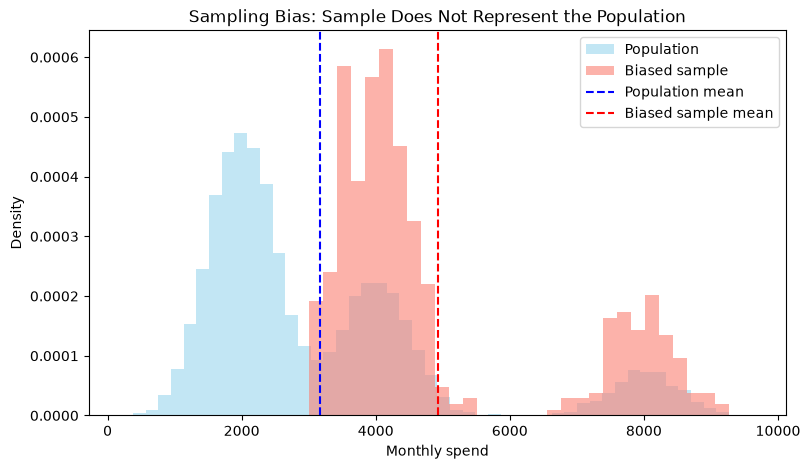

In [6]:
# Biased sample: only customers who spend more than 3000 (like a "premium offer" survey)
biased_pool = population[population["spend"] > 3000]
biased_sample = biased_pool.sample(n=500, random_state=42)

print("Population mean spend:", round(population["spend"].mean(), 2))
print("Random sample mean   :", round(random_sample["spend"].mean(), 2))
print("Biased sample mean   :", round(biased_sample["spend"].mean(), 2))
print("\nVIP share in biased sample:", round((biased_sample["segment"] == "VIP").mean(), 3))
print("VIP share in population   :", round((population["segment"] == "VIP").mean(), 3))

plt.figure(figsize=(9, 5))
plt.hist(population["spend"], bins=50, alpha=0.5, density=True, label="Population", color="skyblue")
plt.hist(biased_sample["spend"], bins=30, alpha=0.6, density=True, label="Biased sample", color="salmon")
plt.axvline(population["spend"].mean(), color="blue", linestyle="--", label="Population mean")
plt.axvline(biased_sample["spend"].mean(), color="red", linestyle="--", label="Biased sample mean")
plt.title("Sampling Bias: Sample Does Not Represent the Population")
plt.xlabel("Monthly spend")
plt.ylabel("Density")
plt.legend()
plt.show()

**Explanation:** We select the sample only from customers who spend more than 3000, so low spenders can never be picked. Then we compare it with the population and the random sample.

**Interpretation:** The biased sample mean is much higher than the true mean, and VIP customers are over-represented. Even with 500 samples, the answer is wrong, because the problem is **how** we selected, not **how many**. **Fix:** use random or stratified sampling, make sure all groups can be selected, and check the sample against known population facts.

## 6. Sampling Error

**Definition:** Sampling error is the **difference between a sample statistic and the true population value** that occurs purely by chance, because we looked at only a part of the population. Unlike bias, it is random and shrinks as the sample gets larger.

**Formula:**

$$\text{Sampling error} = \bar{x} - \mu$$

$$\text{Standard Error (SE)} = \frac{\sigma}{\sqrt{n}}$$

The standard error measures how much sample means vary from sample to sample.

**Numerical Example:** σ = 800, n = 100 → SE = 800 / 10 = **80**. With n = 400 → SE = 800 / 20 = **40**. To halve the error, we need **4 times** the sample size.

**Business Example:** Two surveys of 200 customers each give average satisfaction of 4.1 and 4.3. The difference is sampling error, not a real change.

**AI/ML Example:** Test accuracy on a small test set is only an estimate. Different test sets give slightly different accuracy, and that variation is sampling error. It is why we use cross-validation and confidence intervals.

True population mean       : 3169.46
Mean of the 1000 sample means: 3172.32
Std of sample means (observed SE): 186.1
Theoretical SE = sigma/sqrt(n)   : 188.07

Smallest error: -597.36 | Largest error: 701.73


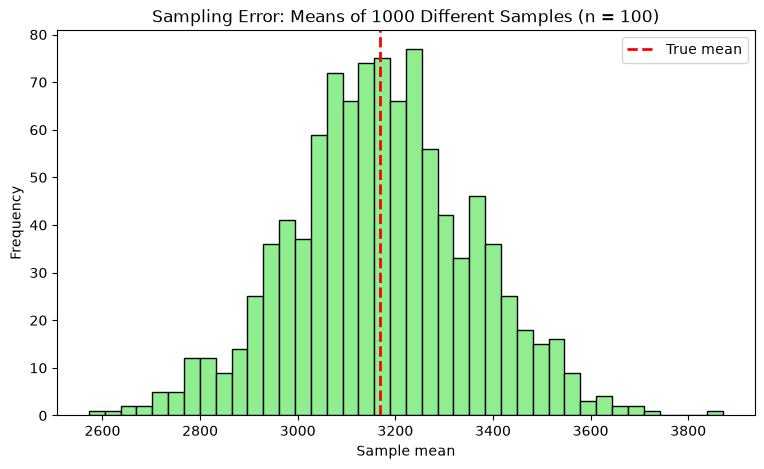

In [7]:
true_mean = population["spend"].mean()
true_std = population["spend"].std()

# Take 1000 different random samples of size 100
sample_means = [population["spend"].sample(n=100, random_state=i).mean() for i in range(1000)]

print("True population mean       :", round(true_mean, 2))
print("Mean of the 1000 sample means:", round(np.mean(sample_means), 2))
print("Std of sample means (observed SE):", round(np.std(sample_means), 2))
print("Theoretical SE = sigma/sqrt(n)   :", round(true_std / np.sqrt(100), 2))

errors = np.array(sample_means) - true_mean
print("\nSmallest error:", round(errors.min(), 2), "| Largest error:", round(errors.max(), 2))

plt.figure(figsize=(9, 5))
plt.hist(sample_means, bins=40, color="lightgreen", edgecolor="black")
plt.axvline(true_mean, color="red", linestyle="--", linewidth=2, label="True mean")
plt.title("Sampling Error: Means of 1000 Different Samples (n = 100)")
plt.xlabel("Sample mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**Explanation:** We draw 1000 samples of size 100, calculate the mean of each, and look at how they vary. The standard deviation of these sample means is the **standard error**, and we compare it with the formula σ / √n.

**Interpretation:** The sample means scatter around the true mean, and their average is very close to it (unbiased). The observed standard error matches σ / √n. Each individual sample has some error, but it is random. The histogram of sample means is bell-shaped, which is the **Central Limit Theorem**.

## 7. Sample Size

**Definition:** Sample size is the number of observations in the sample. A larger sample reduces sampling error, but it also costs more time and money, so we choose the **smallest size that gives the accuracy we need**.

**Formula (to estimate a mean):**

$$n = \left(\frac{z \cdot \sigma}{E}\right)^2$$

**Formula (to estimate a proportion):**

$$n = \frac{z^2 \cdot p(1-p)}{E^2}$$

where z = 1.96 for 95% confidence, σ = standard deviation, E = margin of error, p = expected proportion (use 0.5 if unknown, which gives the largest n).

**Numerical Example (mean):** σ = 800, margin of error E = 50, 95% confidence:
n = (1.96 × 800 / 50)² = (31.36)² = 983.4, so **n = 984**

**Numerical Example (proportion):** p = 0.5, E = 0.05 (±5%):
n = (1.96² × 0.25) / 0.05² = 0.9604 / 0.0025 = 384.2, so **n = 385**

**Business Example:** An election poll of about 400 to 1000 people gives a ±3% to ±5% margin of error, even for a country of millions.

**AI/ML Example:** Too little training data causes overfitting and unreliable test metrics. We check **learning curves** to see if more data would help. For A/B testing, we calculate the required sample size before starting the experiment.

Sample size to estimate mean (E=50)   : 984
Sample size to estimate proportion (+-5%): 385
n =    10 -> Standard error = 594.75
n =    50 -> Standard error = 265.98
n =   100 -> Standard error = 188.07
n =   500 -> Standard error = 84.11
n =  1000 -> Standard error = 59.47
n =  5000 -> Standard error = 26.60


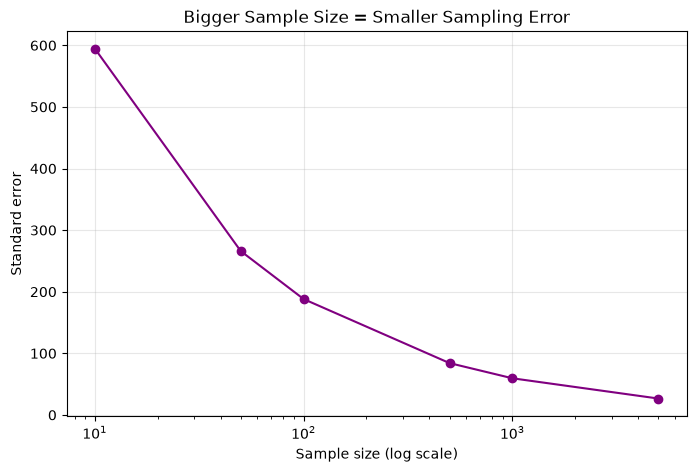

In [8]:
z = 1.96
sigma = 800
E = 50

n_mean = (z * sigma / E) ** 2
print("Sample size to estimate mean (E=50)   :", int(np.ceil(n_mean)))

p, E_prop = 0.5, 0.05
n_prop = (z ** 2) * p * (1 - p) / E_prop ** 2
print("Sample size to estimate proportion (+-5%):", int(np.ceil(n_prop)))

# Effect of sample size on standard error
sizes = [10, 50, 100, 500, 1000, 5000]
se_values = [true_std / np.sqrt(s) for s in sizes]

for s, se in zip(sizes, se_values):
    print(f"n = {s:>5} -> Standard error = {se:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(sizes, se_values, marker="o", color="purple")
plt.xscale("log")
plt.title("Bigger Sample Size = Smaller Sampling Error")
plt.xlabel("Sample size (log scale)")
plt.ylabel("Standard error")
plt.grid(True, alpha=0.3)
plt.show()

**Explanation:** We calculate the required sample size from the formulas, then show how the standard error falls as the sample size increases.

**Interpretation:** About 984 customers are needed to estimate the mean spend within ±50 with 95% confidence, and about 385 people are needed to estimate a proportion within ±5%. The curve drops quickly at first and then flattens: going from 10 to 100 samples helps a lot, but going from 1000 to 5000 helps much less. This is the **law of diminishing returns**, because error shrinks with √n.

Population mean: 3169.46
           Method  Sample size  Sample mean  Error vs population
0          Random          500      3296.40               126.94
1      Stratified          500      3194.34                24.88
2         Cluster         4028      3181.54                12.08
3      Systematic          500      3145.35               -24.11
4  Biased (wrong)          500      4921.87              1752.41


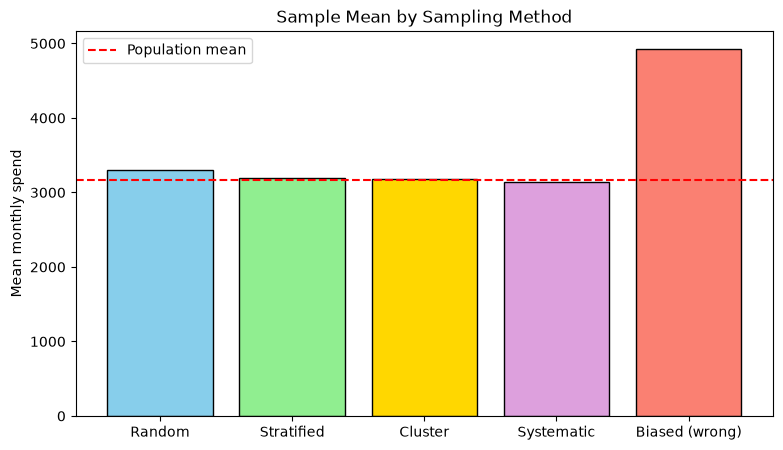

In [9]:
true_mean = population["spend"].mean()

results = pd.DataFrame({
    "Method": ["Random", "Stratified", "Cluster", "Systematic", "Biased (wrong)"],
    "Sample size": [len(random_sample), len(stratified_sample), len(cluster_sample),
                    len(systematic_sample), len(biased_sample)],
    "Sample mean": [random_sample["spend"].mean(), stratified_sample["spend"].mean(),
                    cluster_sample["spend"].mean(), systematic_sample["spend"].mean(),
                    biased_sample["spend"].mean()],
})
results["Error vs population"] = (results["Sample mean"] - true_mean).round(2)
results["Sample mean"] = results["Sample mean"].round(2)

print("Population mean:", round(true_mean, 2))
print(results)

plt.figure(figsize=(9, 5))
plt.bar(results["Method"], results["Sample mean"],
        color=["skyblue", "lightgreen", "gold", "plum", "salmon"], edgecolor="black")
plt.axhline(true_mean, color="red", linestyle="--", label="Population mean")
plt.title("Sample Mean by Sampling Method")
plt.ylabel("Mean monthly spend")
plt.legend()
plt.show()

**Explanation:** We put all the samples taken above into one table and compare each sample mean with the population mean.

**Interpretation:** Random, stratified, cluster and systematic samples are all close to the population mean (small error). The biased sample is far away, even though it has a similar size. **How we sample matters more than how big the sample is.**

## Summary: Which Sampling Method to Use?

| Method | How it works | Best used when | Main risk |
|---|---|---|---|
| Random | Every member has equal chance | Population is large and fairly uniform | May miss small groups |
| Stratified | Sample from every group in proportion | Population has clear subgroups, imbalanced classes | Needs group information in advance |
| Cluster | Select whole groups randomly | Population is spread out, data collection is costly | Higher error if clusters differ |
| Systematic | Every k-th member | Ordered list, quick and simple | Hidden patterns cause bias |

| Concept | Meaning | Reduced by |
|---|---|---|
| Sampling bias | Sample is not representative (systematic) | Better sampling design |
| Sampling error | Random difference between sample and population | Larger sample size |

## Advantages
- Saves time, cost and effort compared with a census
- Makes it possible to study huge or infinite populations
- A well-designed sample gives reliable estimates with a measurable error
- Stratified sampling keeps rare groups represented (very useful for imbalanced data)

## Limitations
- Sampling error always exists, because we see only part of the data
- A badly designed sample gives biased and misleading results, no matter how large it is
- Some methods need extra information (strata, cluster lists)
- Small samples give unstable results and wide confidence intervals